# Telco Customer Churn — Exploratory Data Analysis

This notebook explores the IBM Telco Customer Churn dataset to understand
the structure of the data, identify data quality issues, and surface
patterns that predict customer churn.

**Key questions we want to answer:**
- What is the overall churn rate, and is there a class imbalance?
- Which customer attributes are most strongly associated with churning?
- Are there any data quality issues we need to address before modelling?

The cleaned dataframe is saved at the end for use in `02_feature_engineering.ipynb`.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline

# Shared palette used across the notebook so every Churn-colored plot is
# visually consistent (and matches the class-balance chart in Section 5).
CHURN_PALETTE = {'No': '#5B9BD5', 'Yes': '#ED7D31'}


## 2. Load the data

We load the raw CSV and take an initial look at its shape, column types,
and the first few rows.


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data types and schema

We inspect column dtypes to catch any surprises.
The `TotalCharges` column is a known gotcha in this dataset,
it is stored as an object (string) even though it should be numeric.
We'll fix that here so downstream analyses are correct.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Fix TotalCharges: coerce to numeric (empty strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)


TotalCharges dtype after fix: float64


## 4. Missing values

After fixing `TotalCharges`, we check for any missing values across all columns.


In [5]:
missing = df.isnull().sum()
missing[missing > 0]


TotalCharges    11
dtype: int64

In [6]:
# TotalCharges NaNs correspond to customers with tenure=0 (brand-new customers).
# We'll drop these rows — they have no meaningful charge history.
print(f"Rows with NaN TotalCharges: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"Shape after dropping NaNs: {df.shape[0]:,} rows × {df.shape[1]} columns")


Rows with NaN TotalCharges: 11
Shape after dropping NaNs: 7,032 rows × 21 columns


## 5. Target variable — Churn rate and class balance

Understanding the class balance is critical before modelling.
An imbalanced target can mislead accuracy-based metrics and may require
techniques like class weighting or resampling.


In [7]:
# Encode target as binary
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

churn_rate = df['Churn_Binary'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")
print(df['Churn'].value_counts())


Overall churn rate: 26.6%
Churn
No     5163
Yes    1869
Name: count, dtype: int64


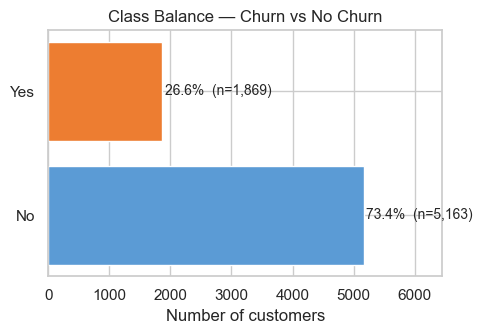

In [8]:
counts = df['Churn'].value_counts()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.barh(counts.index, counts.values,
                color=[CHURN_PALETTE[c] for c in counts.index])
for bar, p, n in zip(bars, pct[counts.index], counts.values):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
            f'{p:.1f}%  (n={n:,})', va='center', fontsize=10)
ax.set_xlabel('Number of customers')
ax.set_title('Class Balance — Churn vs No Churn')
ax.set_xlim(0, counts.max() * 1.25)
plt.tight_layout()
plt.savefig('../data/plots/class_balance.png', dpi=150)
plt.show()


**Finding:** The dataset is moderately imbalanced, roughly 26.5% of customers
churned. This is not severe enough to require aggressive resampling, but we
should use a metric like **AUC-ROC** or **F1** rather than raw accuracy when
evaluating models.


## 6. Numeric features vs Churn

We examine the three continuous features: `tenure`, `MonthlyCharges`,
and `TotalCharges`, split by churn status.


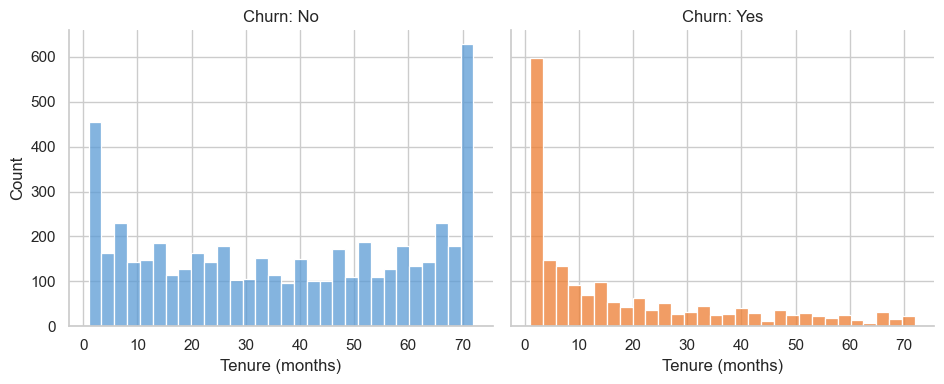

In [9]:
# Tenure
g = sns.FacetGrid(df, col='Churn', hue='Churn', palette=CHURN_PALETTE, height=4, aspect=1.2)
g.map(sns.histplot, 'tenure', bins=30)
g.set_axis_labels('Tenure (months)', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/tenure_churn.png', dpi=150)
plt.show()


**Finding:** Churners are heavily skewed toward *short* tenures.
Non-churners show a more bimodal distribution — many brand-new customers
AND many long-tenured loyal customers stay. Tenure is likely our strongest
single predictor.


**Significance check:** is the tenure gap between churners and non-churners statistically real, or could it be noise?


In [10]:
tenure_churn = df.loc[df['Churn'] == 'Yes', 'tenure']
tenure_stay = df.loc[df['Churn'] == 'No', 'tenure']

u_stat, p_val = stats.mannwhitneyu(tenure_churn, tenure_stay, alternative='two-sided')
print(f"Median tenure — churned: {tenure_churn.median():.0f} mo | stayed: {tenure_stay.median():.0f} mo")
print(f"Mann-Whitney U = {u_stat:,.0f}, p = {p_val:.2e}")


Median tenure — churned: 10 mo | stayed: 38 mo
Mann-Whitney U = 2,494,979, p = 6.04e-211


Given that tenure is not normally distributed for either Churn status, a t-test would not be appropriate, so a Mann-Whitney U test is preferred since it's non-parametric. Instead of comparing means, this test asks: "if I grabbed a random churner and a random non-churner, how often would the churner have the lower tenure?" A significant result means that probability is meaningfully different from 50/50 i.e., not what we'd expect if tenure had no relationship to churn.

The median gap between the two groups (10 months (churned) vs. 38 months (stayed)) is substantial: non-churners have a median tenure over two years higher than churners. The descriptive gap alone already suggests that customers with longer tenures are far more likely to stay.

The resulting p-value, 6.04e-211, is vanishingly small: churners are significantly more likely to have shorter tenures than non-churners. This says nothing about the *magnitude* of the effect but it does confirm this relationship is not due to chance, and tenure looks like it will be an important feature for downstream modeling.

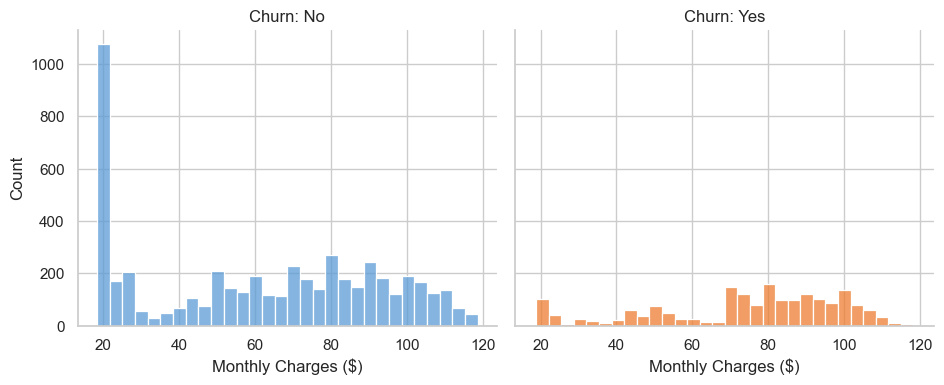

In [11]:
# Monthly Charges
g = sns.FacetGrid(df, col='Churn', hue='Churn', palette=CHURN_PALETTE, height=4, aspect=1.2)
g.map(sns.histplot, 'MonthlyCharges', bins=30)
g.set_axis_labels('Monthly Charges ($)', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/monthly_charges_churn.png', dpi=150)
plt.show()


**Finding:** Churners tend to have *higher* monthly charges on average.
Non-churners show a large cluster of low-charge customers. These may be
on basic plans and are apparently quite sticky.


**Significance check:** same test for monthly charges.

In [12]:
charges_churn = df.loc[df['Churn'] == 'Yes', 'MonthlyCharges']
charges_stay = df.loc[df['Churn'] == 'No', 'MonthlyCharges']

u_stat, p_val = stats.mannwhitneyu(charges_churn, charges_stay, alternative='two-sided')
print(f"Median MonthlyCharges — churned: ${charges_churn.median():.2f} | stayed: ${charges_stay.median():.2f}")
print(f"Mann-Whitney U = {u_stat:,.0f}, p = {p_val:.2e}")


Median MonthlyCharges — churned: $79.65 | stayed: $64.45
Mann-Whitney U = 5,986,148, p = 8.47e-54


The result is significant, though not to the same magnitude as the tenure test the p-value is still substantially small. This means churners are significantly more likely to be associated with higher monthly charges. The difference in medians is ~$15, which doesn't seem especially large on its own, whether it matters in practice depends on the company's priorities.

What's actually driving this result is that customers with the lowest monthly charges are overwhelmingly non-churners: excluding customers under $25/month, the gap between churners and non-churners shrinks substantially (to about $4.50 in median terms), though it doesn't disappear entirely it remains statistically significant given the sample size. This is worth flagging now, since it could complicate interpretation in downstream ML analyses: the "high monthly charges → churn" signal is really being driven by a specific low-cost segment rather than a uniform effect across the whole price range.

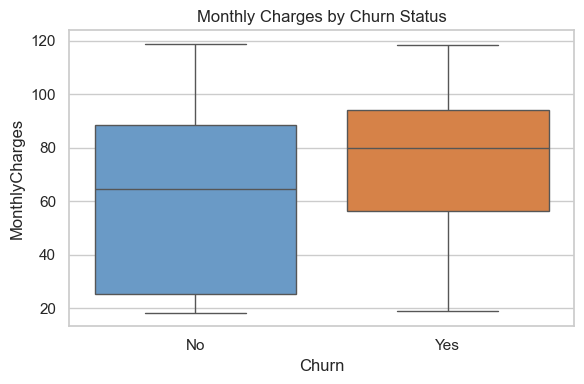

In [13]:
# Box plot: Monthly Charges by Churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette=CHURN_PALETTE, legend=False, ax=ax)
ax.set_title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig('../data/plots/charges_boxplot.png', dpi=150)
plt.show()


## 7. Categorical features vs Churn

We compute churn rate for each categorical variable to identify
the highest-signal groups.


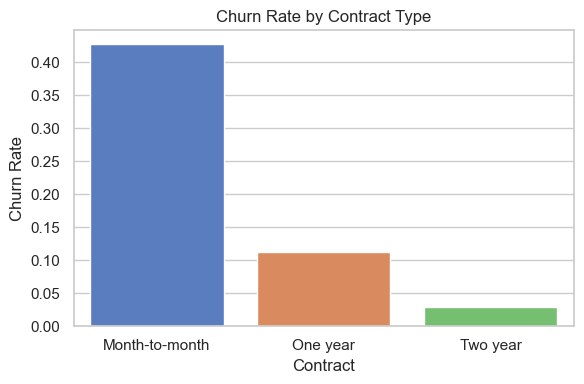

In [14]:
# Contract type
contract_churn = (df.groupby('Contract')['Churn_Binary']
                    .mean()
                    .reset_index()
                    .rename(columns={'Churn_Binary': 'Churn Rate'}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=contract_churn, x='Contract', y='Churn Rate',
            hue='Contract', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/contract_churn.png', dpi=150)
plt.show()


**Finding:** Month-to-month customers churn at ~42%, roughly 3× the rate
of customers on annual or two-year contracts. Contract type will be a key
feature for the model.


**Significance check:** chi-square test of independence between contract type and churn.

In [15]:
contract_table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(contract_table)
print(f"Chi-square = {chi2:.1f}, dof = {dof}, p = {p_val:.2e}")


Chi-square = 1179.5, dof = 2, p = 7.33e-257


Given that Contract and Churn are both categorical variables, chi-square is the appropriate test here. It compares what we observe in the data against what we'd expect if there were no relationship between contract type and churn: a big chi-square statistic (and correspondingly small p-value) indicates a dependent relationship between the variables.

The test returned a large chi-square statistic and a tiny p-value, confirming that the differences we observed visually in the bar chart between contract types are not due to chance: month-to-month contracts are significantly more likely to churn than one- or two-year contracts. This test only tells us the relationship is real, not how strong it is; Section 8.1's Cramér's V ranking picks up that question, where Contract turns out to be the single strongest categorical predictor of churn in the dataset.

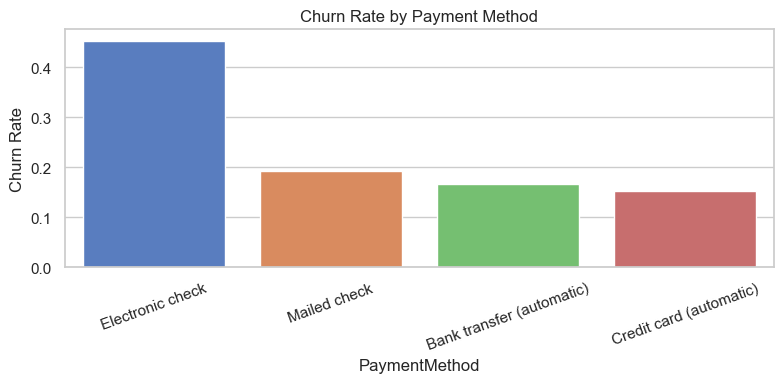

In [16]:
# Payment method
payment_churn = (df.groupby('PaymentMethod')['Churn_Binary']
                   .mean()
                   .sort_values(ascending=False)
                   .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Binary',
            hue='PaymentMethod', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Payment Method')
ax.set_ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../data/plots/payment_churn.png', dpi=150)
plt.show()


**Finding:** Electronic check users churn at ~45%, roughly double the
rate of customers using automatic payment methods. This likely reflects
lower commitment or financial friction rather than a causal relationship.


**Significance check:** same test for payment method.

In [17]:
payment_table = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(payment_table)
print(f"Chi-square = {chi2:.1f}, dof = {dof}, p = {p_val:.2e}")


Chi-square = 645.4, dof = 3, p = 1.43e-139


The chi-square statistic is lower than for Contract, and the p-value is slightly larger but still tiny, there's clearly a dependent relationship between payment method and churn. It's worth being specific about where that relationship comes from, though: the substantial difference sits almost entirely between Electronic check (45.3% churn) and the other three methods, which cluster tightly between 15.3% and 19.2%. Mailed check, bank transfer, and credit card behave similarly to each other, so it may be worth collapsing this into a binary feature (Electronic check vs. all others) before modeling, rather than keeping all four categories.

### 7.1 Systematic churn-rate summary for all categorical variables

Rather than plotting every column individually, we produce a ranked
summary table of churn rate by category value, useful for quickly
spotting high-risk segments.


In [18]:
cat_cols = df.select_dtypes(include='str').columns.drop(['customerID', 'Churn'])

rows = []
for col in cat_cols:
    for val, grp in df.groupby(col):
        rows.append({
            'Feature': col,
            'Value': val,
            'Churn Rate': grp['Churn_Binary'].mean(),
            'N': len(grp),
        })

summary = (pd.DataFrame(rows)
             .sort_values('Churn Rate', ascending=False)
             .reset_index(drop=True))

# Filter out tiny segments (N < 30) so we're not ranking noise, then show
# the table capped at a readable size.
summary_filtered = summary[summary['N'] >= 30].reset_index(drop=True)
pd.set_option('display.max_rows', 20)
summary_filtered.head(15)


,Feature,Value,Churn Rate,N
0,PaymentMethod,Electronic check,0.452854,2365
1,Contract,Month-to-month,0.427097,3875
2,InternetService,Fiber optic,0.418928,3096
3,OnlineSecurity,No,0.417787,3497
4,TechSupport,No,0.416475,3472
5,OnlineBackup,No,0.399417,3087
6,DeviceProtection,No,0.391403,3094
7,StreamingMovies,No,0.337289,2781
8,PaperlessBilling,Yes,0.335893,4168
9,StreamingTV,No,0.335351,2809


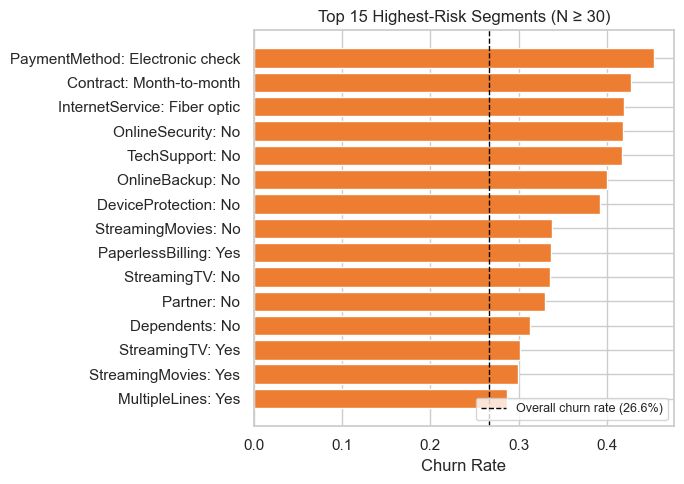

In [19]:
top15 = summary_filtered.head(15).copy()
top15['label'] = top15['Feature'] + ': ' + top15['Value'].astype(str)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top15['label'][::-1], top15['Churn Rate'][::-1], color='#ED7D31')
overall_rate = df['Churn_Binary'].mean()
ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall churn rate ({overall_rate:.1%})')
ax.set_xlabel('Churn Rate')
ax.set_title('Top 15 Highest-Risk Segments (N ≥ 30)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/plots/top_risk_segments.png', dpi=150)
plt.show()


## 8. Number of subscribed services vs Churn

A rough proxy for customer engagement is how many add-on services they
subscribe to (phone, internet, security, backup, etc.).
We compute this here for exploratory purposes; it will be engineered
properly in `02_feature_engineering.ipynb`.


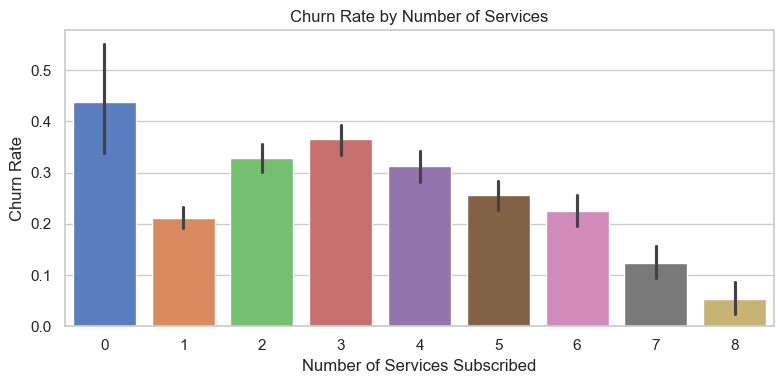

In [20]:
service_cols = ['PhoneService', 'MultipleLines',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='num_services', y='Churn_Binary',
            hue='num_services', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Number of Services')
ax.set_xlabel('Number of Services Subscribed')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/services_churn.png', dpi=150)
plt.show()


**Finding:** Customers with fewer services churn at a higher rate.
Customers subscribed to 5+ services are much more likely to stay,
possibly because switching costs are higher or because high engagement
correlates with satisfaction.


## 8.1 Association strength of categorical features with Churn

Pearson correlation only applies to numeric features. For categoricals, we
use **Cramér's V** (derived from the chi-square statistic) to rank which
categorical features are most strongly associated with churn — the
categorical equivalent of the correlation ranking in Section 9.

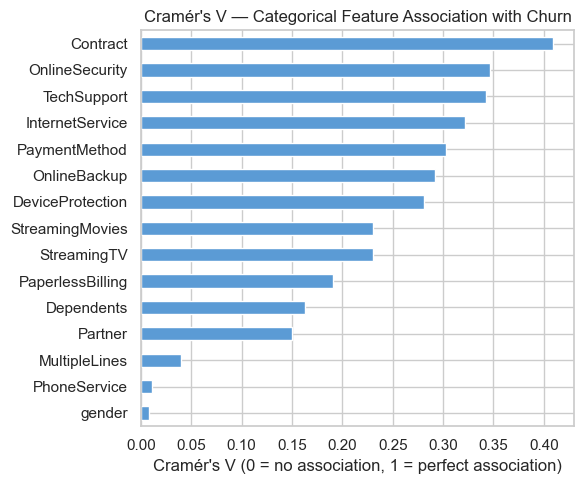

Contract            0.409560
OnlineSecurity      0.346992
TechSupport         0.342506
InternetService     0.321909
PaymentMethod       0.302960
OnlineBackup        0.291902
DeviceProtection    0.281159
StreamingMovies     0.230702
StreamingTV         0.230143
PaperlessBilling    0.191127
Dependents          0.162777
Partner             0.149660
MultipleLines       0.040036
PhoneService        0.011147
gender              0.008223
dtype: float64


In [21]:
def cramers_v(col):
    table = pd.crosstab(df[col], df['Churn'])
    chi2 = stats.chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

cat_cols_assoc = df.select_dtypes(include='str').columns.drop(['customerID', 'Churn'])
assoc = pd.Series({col: cramers_v(col) for col in cat_cols_assoc}).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
assoc.plot(kind='barh', ax=ax, color='#5B9BD5')
ax.set_title("Cramér's V — Categorical Feature Association with Churn")
ax.set_xlabel("Cramér's V (0 = no association, 1 = perfect association)")
plt.tight_layout()
plt.savefig('../data/plots/cramers_v.png', dpi=150)
plt.show()
print(assoc.sort_values(ascending=False))


**Finding:** Chi-square tells you *whether* an association exists, but its scale isn't directly comparable across features with different numbers of categories. Contract has 3 values, PaymentMethod has 4, which changes chi-square's scale on its own. Cramér's V normalizes this onto a consistent 0–1 range, so it can actually rank features against each other.

The ranking shows `Contract` (0.41) as the single strongest categorical predictor, followed by `OnlineSecurity` (0.35), `TechSupport` (0.34), and `InternetService` (0.32). `PaymentMethod` (0.30) is moderately associated, consistent with the chi-square test above. At the other end, `gender` (0.008) and `PhoneService` (0.011) show essentially no association with churn, an early signal that demographic fields aren't going to be useful predictors here, and can likely be set aside in feature engineering.

## 9. Correlation of numeric features with Churn

A quick Pearson correlation gives us a directional signal for the
numeric columns. Note that most of the predictive signal in this dataset
is in the categorical columns, which this matrix does not capture.


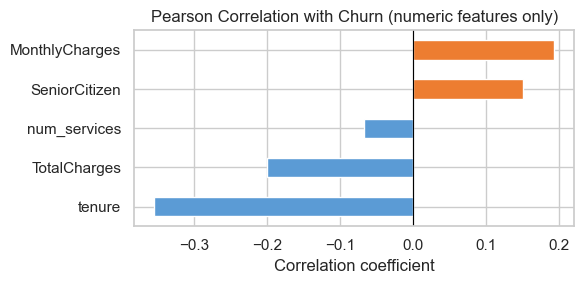

tenure           -0.354049
TotalCharges     -0.199484
num_services     -0.067459
SeniorCitizen     0.150541
MonthlyCharges    0.192858
Name: Churn_Binary, dtype: float64


In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = (df[numeric_cols]
          .corr()['Churn_Binary']
          .drop('Churn_Binary')
          .sort_values())

fig, ax = plt.subplots(figsize=(6, 3))
corr.plot(kind='barh', ax=ax, color=['#ED7D31' if v > 0 else '#5B9BD5' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Churn (numeric features only)')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('../data/plots/numeric_correlation.png', dpi=150)
plt.show()
print(corr)


**Finding:**
- `tenure` has the strongest (negative) correlation with churn: longer-tenured
  customers are much less likely to leave.
- `MonthlyCharges` is positively correlated: higher bills → more churn risk.
- `TotalCharges` is negatively correlated — but this largely reflects tenure
  (long-tenured customers accumulate high totals). These two features are
  collinear; we'll handle that in feature engineering.


## 10. EDA Summary and key takeaways

| Signal | Finding | Statistical test |
|--------|---------|-------------------|
| Churn rate | 26.6%, moderate class imbalance; use AUC-ROC / F1 for evaluation | — |
| Tenure | Strongest numeric predictor; short tenure → high churn risk; corr: -0.354049 | Mann-Whitney U, p = 6.04e-211 |
| Monthly charges | Churners pay more on average; corr: 0.192858. Effect is driven mostly by a low-charge (<$25) segment, gap shrinks from ~$15 to ~$4.50 above that threshold | Mann-Whitney U, p = 8.47e-54 |
| Contract type | Month-to-month → 42.7% churn; one year → 11.3%; two year → 2.8%. Strongest categorical predictor overall (Cramér's V = 0.41) | Chi-square, p = 7.33e-257 |
| Payment method | Electronic check → 45.3% churn vs. 15.3–19.2% for other methods; consider collapsing to a binary feature before modeling | Chi-square, p = 1.43e-139 |
| Categorical association ranking | Cramér's V ranks Contract, OnlineSecurity, TechSupport, and InternetService as the strongest categorical predictors; gender and PhoneService are essentially unassociated with churn (V < 0.02) and are candidates to drop | Cramér's V |
| Services | Fewer services → higher churn risk | — |
| TotalCharges | Largely redundant with tenure; monitor for multicollinearity | — |

**Next steps (`02_feature_engineering.ipynb`):**
- Encode categorical variables
- Engineer `num_services` and `avg_charge_per_month`
- Collapse `PaymentMethod` into a binary Electronic-check-vs-other feature
- Drop or de-prioritize `gender` and `PhoneService` given near-zero Cramér's V
- Handle the `tenure` / `TotalCharges` collinearity
- Scale numeric features for distance-based models

## 11. Save cleaned dataframe

Drop the temporary `num_services` column (will be re-engineered in notebook 02)
and save the cleaned, type-corrected dataframe for downstream use.


In [23]:
df_clean = df.drop(columns=['num_services'])
df_clean.to_csv('../data/telco_cleaned.csv', index=False)
print(f"Saved telco_cleaned.csv  ({df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns)")


Saved telco_cleaned.csv  (7,032 rows × 22 columns)
